## 22 June 2026
## Sapkas Michail
### Lunar Lander - Final Project for Deep Neural Networks

Implement the Actor-Critic

# Deep Deterministic Policy Gradient (DDPG) algorithm

In [ ]:
import torch
import random
from collections import deque
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import time
import os

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")  # For Mac Apple Silicon users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


Defining all the hyperparameters of the algorithm: 

- **CRITIC/ACTOR LATENT_DIM** is the dimension of the hidden layer of the neural network
- **BATCH_SIZE** is the number of samples randomly sampled from the replay buffer to train the network
- **LEARNING_RATE CRITIC/ACTOR** is self explanatory. I am using adam
- **GAMMA** is the discount factor for future rewards (in this context, because it is multiplying the estimated future rewards Q it can also represent the "trust" or "importance" of our estimation)
- **TAU** is the soft update parameter using the polyak method for updating the target network
- **MIN_REPLAY_SIZE** is the warm-up samples (random actions) that fill the replay buffer before training starts
- **REPLAY_BUFFER_SIZE** is the capacity of the replay buffer
- **TRAIN_FREQ** is the frequency of training the network in steps
- **TARGET_UPDATE_FREQ** is the frequency of updating the target network in steps
- **SIGMA_START** is the initial value of sigma (the standard deviation) for the gaussian noise induced in the actions as exploration strategy
- **SIGMA_DECAY** is the multiplicative factor by which sigma is decayed after each episode
- **SIGMA_MIN** is the minimum value of sigma
- **TOTAL_TIMESTEPS** is self explanatory. The total number of steps until the training is finished **NOT USED FOR TRAINING** 
- **N_CONSECUTIVE** is the number of consecutive episodes that the 100-episode average must stay above 200 for the environment to be considered solved

In [ ]:
CRITIC_LATENT_DIM = ACTOR_LATENT_DIM = 128
BATCH_SIZE = 64
LR_CRITIC = LR_ACTOR = 1e-3

GAMMA = 0.99
TAU = 0.005

MIN_REPLAY_SIZE = 10_000
REPLAY_BUFFER_SIZE = 300_000

TARGET_UPDATE_FREQ = TRAIN_FREQ = 4
# TARGET_UPDATE_FREQ = 10

SIGMA_START = 1.0
SIGMA_DECAY = 0.998
SIGMA_MIN = 0.05

N_CONSECUTIVE = 10  # Number of episodes the 100-Ep Avg must stay >= 200
# TOTAL_TIMESTEPS = 300_000

We ve seen the decay function for epsilon in the DQN notebook. The same applies for sigma, teh standard deviation of the noise we add on top of the continuous action output by the Actor.

In [31]:
def update_sigma_decay(sigma):
    return max(SIGMA_MIN, sigma * SIGMA_DECAY)

The Actor Network takes as input the state of the environment (vector of 8 floats) and outputs continuous actions (vector of 2 floats from -1 to 1). It is composed by 2 Linear Layers that end in a Tanh output.

The Critic Network takes both the State and the Action output by the Actor, a concatenation of the 8-dim environmental state vector and the 2-dim action vector and outputs 1 Value which is the estimation of the future cumulative reward for that state-action tuple.

In [ ]:
OBSERVATION_SPACE = 8
ACTION_SPACE = 2

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE, ACTOR_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(ACTOR_LATENT_DIM, ACTOR_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(ACTOR_LATENT_DIM, ACTION_SPACE),
            nn.Tanh()                                        # Actions are in range [-1, 1]
        )
    def forward(self, state):
        return self.network(state)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(OBSERVATION_SPACE + ACTION_SPACE, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, CRITIC_LATENT_DIM),
            nn.ReLU(),
            nn.Linear(CRITIC_LATENT_DIM, 1),
        )
    def forward(self, state, action):
        combined_features = torch.cat([state, action], dim=1)
        return self.network(combined_features)

# Main networks
actor = Actor().to(device)
critic = Critic().to(device)

# Target networks
actor_target = Actor().to(device)
critic_target = Critic().to(device)
actor_target.load_state_dict(actor.state_dict())
critic_target.load_state_dict(critic.state_dict())

# Balanced Learning Rates (Critic learns faster than Actor to provide stable gradients)
actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)
loss_fn = nn.MSELoss()

The main difference with DQN is that we are using the Critic Network to estimate the Q-value and the continuous action that the Actor Network took. The idea of the training is the same:

- Sample randomly from the replay buffer
- Logistics: unpack and convert to tensors, move to device (GPU or CPU)
- Given the current state, do a forward pass on the Actor Network to get the next continuous action
- Given the next action, do a forward pass on the Critic Network to get an estimation of the future value given that one action
- Then train exactly with the Loss functions are given in the slides.
- The "gradient ascent" is performed "manually" by using the minus sign in from of the critic output values. 1/m corresponds to the mean method.

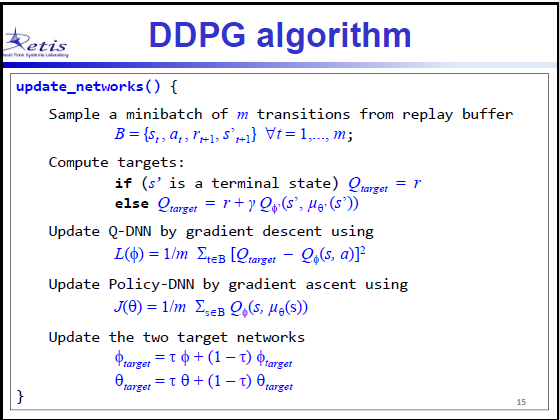

In [33]:
# TRAINING STEP
def train_step():

    mini_batch = random.sample(replay_buffer, BATCH_SIZE)
    states, actions, rewards, next_states, dones = zip(*mini_batch)

    states = torch.FloatTensor(np.array(states)).to(device)
    actions = torch.FloatTensor(np.array(actions)).to(device)
    rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
    next_states = torch.FloatTensor(np.array(next_states)).to(device)
    dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

    # Put networks into explicit training mode
    actor.train()
    critic.train()

    # Forward pass on the target networks, no need to keep track of the gradients
    with torch.no_grad():
        next_actions = actor_target(next_states)
        next_q_values = critic_target(next_states, next_actions)
        target_q_values = rewards + (GAMMA * next_q_values * (1 - dones))

    # CRITIC
    current_q_values = critic(states, actions)
    critic_loss = loss_fn(current_q_values, target_q_values)
    
    critic_optimizer.zero_grad()
    critic_loss.backward()
    critic_optimizer.step()

    # ACTOR
    # We predict new actions from the current states to maintain the gradient chain
    predicted_actions = actor(states)
    actor_loss = -critic(states, predicted_actions).mean()  # - sign performs gradient ascent
    
    actor_optimizer.zero_grad()
    actor_loss.backward()
    actor_optimizer.step()

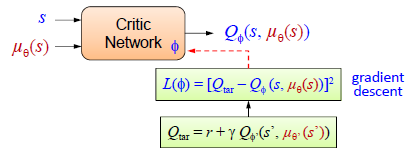

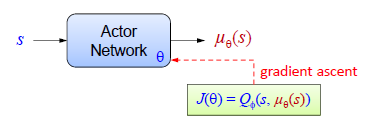

Enviroment and training loop:

In [ ]:
replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
sigma = SIGMA_START

# STATISTICS TRACKING
episode_rewards = []
episode_lengths = []
moving_avg_rewards = []
current_episode_reward = 0
current_episode_length = 0
prev_avg_reward = None

# ENVIRONMENT LOOP
env = gym.make("LunarLander-v3", continuous=True)
observation, info = env.reset(seed=42)

print("Initializing training loop...", flush=True)

pbar = tqdm(desc="Training", leave=True)
pbar.set_postfix({"Ep": 0, "100-Ep Avg": 0.0, "Status": "Warming Up"})

step = 0
solved = False
consecutive_solved_episodes = 0  # Counter to track stable performance

while not solved:
    pbar.update(1)
    step += 1

    # Warm-up condition check
    if len(replay_buffer) < MIN_REPLAY_SIZE:
        action = env.action_space.sample()
    else:
        actor.eval()
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
        with torch.no_grad():
            action = actor(state_tensor).squeeze(0).cpu().numpy()
        
        action = action + np.random.normal(0, sigma, size=2)
        action = np.clip(action, -1.0, 1.0)

    next_observation, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
        
    current_episode_reward += reward
    current_episode_length += 1

    replay_buffer.append((observation, action, reward, next_observation, done))
    observation = next_observation

    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
        train_step()

    if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
        with torch.no_grad():
            for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)
                
            for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)

    # Handle Episode Termination
    if done:
        episode_rewards.append(current_episode_reward)
        episode_lengths.append(current_episode_length)

        avg_reward = np.mean(episode_rewards[-100:])
        moving_avg_rewards.append(avg_reward)

        status_msg = "Warming Up" if len(replay_buffer) < MIN_REPLAY_SIZE else "Learning"

        if len(replay_buffer) >= MIN_REPLAY_SIZE:
            sigma = update_sigma_decay(sigma)

        pbar.set_postfix({
            "Ep": len(episode_rewards),
            "Last Reward": f"{current_episode_reward:.1f}",
            "100-Ep Avg": f"{avg_reward:.1f}",
            "Hold Count": f"{consecutive_solved_episodes}/{N_CONSECUTIVE}",
            "Mode": status_msg
        })

        # --- STABILITY CONDITION CHECK ---
        # 1. Check if the baseline criteria of 100 episodes and >= 200 average is met
        if len(episode_rewards) >= 100 and avg_reward >= 200.0:
            consecutive_solved_episodes += 1
        else:
            # If it drops below 200 even once, the consecutive streak resets to 0
            consecutive_solved_episodes = 0

        # 2. Check if the streak has successfully hit N episodes
        if consecutive_solved_episodes >= N_CONSECUTIVE:
            print(f"\n\nEnvironment solved permanently! 100-Ep Avg held >= 200 for {N_CONSECUTIVE} consecutive episodes.")
            solved = True
            break
        # ---------------------------------

        observation, info = env.reset()
        current_episode_reward = 0
        current_episode_length = 0

env.close()
pbar.close()
print("\nTraining Complete!")

Training: 333549it [13:52, 400.47it/s, Ep=475, Last Reward=-0.8, 100-Ep Avg=74.5, Hold Count=0/10, Mode=Learning]

Initializing training loop...



Training: 583203it [10:10, 955.04it/s, Ep=779, Last Reward=270.3, 100-Ep Avg=204.6, Hold Count=9/10, Mode=Learning]   



Environment solved permanently! 100-Ep Avg held >= 200 for 10 consecutive episodes.

Training Complete!


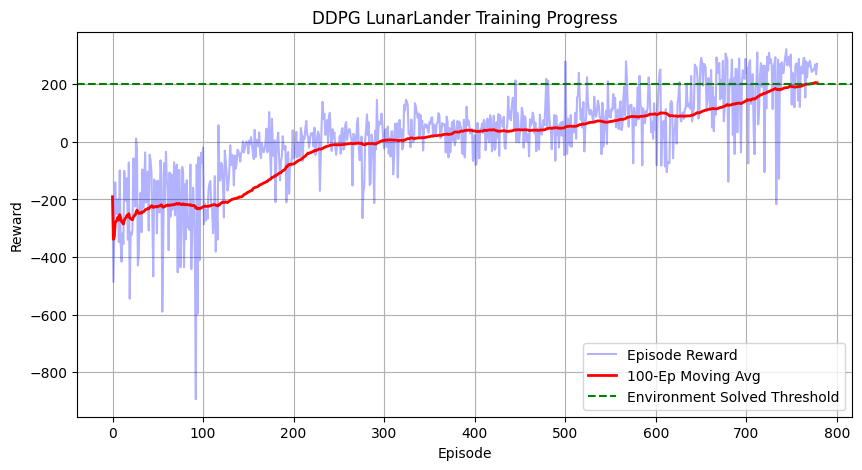

In [36]:
plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, color="blue", label="Episode Reward")
plt.plot(moving_avg_rewards, color="red", linewidth=2, label="100-Ep Moving Avg")
plt.axhline(y=200, color="green", linestyle="--", label="Environment Solved Threshold")
plt.title("DDPG LunarLander Training Progress")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.legend()
plt.grid(True)
plt.savefig("ddpg_lunar_lander_progress.png")
plt.show()

In [37]:
# Save weights
torch.save(actor.state_dict(), "ddpg_actor_lunar_lander.pth")
print("Actor model saved to ddpg_actor_lunar_lander.pth")

Actor model saved to ddpg_actor_lunar_lander.pth


In [38]:
test_actor = Actor().to(device)
test_actor.load_state_dict(torch.load("ddpg_actor_lunar_lander.pth", map_location=device))
test_actor.eval()  # Set network to evaluation mode (turns off dropout, batchnorm etc.)
 
# Determine the device the actor is currently living on (handles CPU/CUDA automatically)
current_device = next(test_actor.parameters()).device

# Initialize environment in "human" render mode with continuous action space
env = gym.make("LunarLander-v3", continuous=True, render_mode="human")

# Run for 5 demonstration episodes
NUM_EPISODES = 5

for episode in range(NUM_EPISODES):
    observation, info = env.reset()
    episode_reward = 0
    done = False

    print(f"Starting DDPG Evaluation Episode {episode + 1}...")

    while not done:
        # Convert observation to tensor and send it to the actor's current device
        state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(current_device)

        # Pure Exploitation: Get raw continuous control values from the Actor
        with torch.no_grad():
            # squeeze(0).cpu().numpy() handles bringing it back safely to system memory
            action = test_actor(state_tensor).squeeze(0).cpu().numpy()

        # Step the environment with continuous controls
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        episode_reward += reward

        # Small sleep delay so the human eye can track the smooth engine firing
        time.sleep(0.01)

    print(f"Episode {episode + 1} Finished! Total Reward: {episode_reward:.1f}\n")

env.close()
print("Evaluation Complete!")

Starting DDPG Evaluation Episode 1...
Episode 1 Finished! Total Reward: 263.0

Starting DDPG Evaluation Episode 2...
Episode 2 Finished! Total Reward: 261.7

Starting DDPG Evaluation Episode 3...
Episode 3 Finished! Total Reward: 282.2

Starting DDPG Evaluation Episode 4...
Episode 4 Finished! Total Reward: 251.5

Starting DDPG Evaluation Episode 5...
Episode 5 Finished! Total Reward: 262.0

Evaluation Complete!


# Code for stability analysis
### 10 Runs of DDPG with different random seeds

In [ ]:
TOTAL_TIMESTEPS = 600000
N_RUNS = 10
SAVE_DIR = "./DDPG_stability_analysis"
os.makedirs(SAVE_DIR, exist_ok=True)

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Starting Stability Analysis for {N_RUNS} runs...", flush=True)

for run in range(N_RUNS):
    print(f"\n--- Starting Run {run + 1}/{N_RUNS} ---")
    
    # File paths for saving this specific run's data
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    # --- INTERRUPTION PROTECTION: CHECK FOR EXISTING DATA ---
    if os.path.exists(reward_file) and os.path.exists(length_file):
        print(f"-> Found existing data for Run {run + 1}. Loading and skipping...")
        run_history = np.load(reward_file).tolist()
        final_episode_count = np.load(length_file).item()  # Loaded as a single value item
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(final_episode_count)
        continue  # Skip to the next run
    
    # 1. RESET / RE-INITIALIZE AGENT & ENVIRONMENT WITH NEW SEEDS
    env = gym.make("LunarLander-v3", continuous=True)
    
    run_seed = 42 + run 
    observation, info = env.reset(seed=run_seed)
    random.seed(run_seed)
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(run_seed)
    
    # Re-initialize DDPG networks per run
    actor = Actor().to(device)
    critic = Critic().to(device)
    
    actor_target = Actor().to(device)
    critic_target = Critic().to(device)
    actor_target.load_state_dict(actor.state_dict())
    critic_target.load_state_dict(critic.state_dict())
    
    actor_optimizer = optim.Adam(actor.parameters(), lr=LR_ACTOR)
    critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC)
    
    replay_buffer = deque(maxlen=REPLAY_BUFFER_SIZE)
    sigma = SIGMA_START
    
    # STATISTICS & ADAPTIVE TRACKING
    episode_rewards = []
    current_episode_reward = 0
    current_episode_length = 0
    run_history = []  # Stores 100-episode moving averages at each step
    
    pbar = tqdm(range(TOTAL_TIMESTEPS), desc=f"Run {run + 1} Progress")
    pbar.set_postfix({"Ep": 0, "Avg": "0.0", "Sigma": f"{sigma:.2f}", "Mode": "Warmup"})

    for step in pbar:
        # Action Selection (Warm-up vs Exploit + Noise)
        if len(replay_buffer) < MIN_REPLAY_SIZE:
            action = env.action_space.sample()
        else:
            actor.eval()
            state_tensor = torch.FloatTensor(observation).unsqueeze(0).to(device)
            with torch.no_grad():
                action = actor(state_tensor).squeeze(0).cpu().numpy()
            
            # Inject Exploration Noise
            action = action + np.random.normal(0, sigma, size=ACTION_SPACE)
            action = np.clip(action, -1.0, 1.0)

        # Step environment
        next_observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        current_episode_reward += reward
        current_episode_length += 1

        # Save transition to replay buffer
        replay_buffer.append((observation, action, reward, next_observation, done))
        observation = next_observation

        # Train networks
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TRAIN_FREQ == 0:
            train_step() # Make sure your train_step interacts with the newly instantiated actor/critic globals or update them inside

        # Soft update target networks (Polyak averaging)
        if len(replay_buffer) >= MIN_REPLAY_SIZE and step % TARGET_UPDATE_FREQ == 0:
            with torch.no_grad():
                for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                    target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)
                for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                    target_param.data.copy_(TAU * param.data + (1.0 - TAU) * target_param.data)

        # Log 100-episode moving average at every single timestep
        avg_reward = np.mean(episode_rewards[-100:]) if episode_rewards else 0.0
        run_history.append(avg_reward)

        # Handle Episode Termination
        if done:
            episode_rewards.append(current_episode_reward)
            
            # Update exploration noise scale
            if len(replay_buffer) >= MIN_REPLAY_SIZE:
                sigma = update_sigma_decay(sigma)

            status_msg = "Warming Up" if len(replay_buffer) < MIN_REPLAY_SIZE else "Learning"

            pbar.set_postfix({
                "Ep": len(episode_rewards),
                "Steps": f"{current_episode_length}",
                "Last Reward": f"{current_episode_reward:.1f}",
                "100-Ep Avg": f"{avg_reward:.1f}",
                "Sigma": f"{sigma:.3f}",
                "Mode": status_msg
            })

            # Reset environment variables for next episode
            observation, info = env.reset()
            current_episode_reward = 0
            current_episode_length = 0
            
    # The final total count of completed episodes for this entire run
    final_episode_count = len(episode_rewards)
    env.close()
    
    # --- SAVE TO NUMPY ARRAYS AFTER EACH RUN ---
    np.save(reward_file, np.array(run_history))
    np.save(length_file, np.array(final_episode_count))  # Saves single scalar integer
    print(f"-> Saved data for Run {run + 1} to {SAVE_DIR}")
    
    all_runs_logs.append(run_history)
    all_runs_lengths_logs.append(final_episode_count)

print("\nAll training runs finished or loaded! Ready for stability analysis visualization.")

Starting Stability Analysis for 10 runs...

--- Starting Run 1/10 ---
-> Found existing data for Run 1. Loading and skipping...

--- Starting Run 2/10 ---


Run 2 Progress: 100%|█████| 600000/600000 [11:21<00:00, 880.35it/s, Ep=923, Steps=232, Last Reward=239.7, 100-Ep Avg=207.0, Sigma=0.188, Mode=Learning]


-> Saved data for Run 2 to ./DDPG_stability_analysis

--- Starting Run 3/10 ---


Run 3 Progress: 100%|████| 600000/600000 [11:08<00:00, 897.24it/s, Ep=1022, Steps=168, Last Reward=275.6, 100-Ep Avg=232.4, Sigma=0.157, Mode=Learning]


-> Saved data for Run 3 to ./DDPG_stability_analysis

--- Starting Run 4/10 ---


...

-> Saved data for Run 8 to ./DDPG_stability_analysis

--- Starting Run 9/10 ---


Run 9 Progress: 100%|█████| 600000/600000 [11:01<00:00, 907.49it/s, Ep=942, Steps=203, Last Reward=255.3, 100-Ep Avg=254.3, Sigma=0.183, Mode=Learning]


-> Saved data for Run 9 to ./DDPG_stability_analysis

--- Starting Run 10/10 ---


Run 10 Progress: 100%|████| 600000/600000 [11:15<00:00, 888.65it/s, Ep=903, Steps=199, Last Reward=292.7, 100-Ep Avg=260.3, Sigma=0.196, Mode=Learning]

-> Saved data for Run 10 to ./DDPG_stability_analysis

All training runs finished or loaded! Ready for stability analysis visualization.


Loading Stability Analysis data for 10 runs from './DDPG_stability_analysis'...
-> Successfully loaded Run 1 (Total Episodes: 838)
-> Successfully loaded Run 2 (Total Episodes: 923)
-> Successfully loaded Run 3 (Total Episodes: 1022)
-> Successfully loaded Run 4 (Total Episodes: 974)
-> Successfully loaded Run 5 (Total Episodes: 842)
-> Successfully loaded Run 6 (Total Episodes: 896)
-> Successfully loaded Run 7 (Total Episodes: 896)
-> Successfully loaded Run 8 (Total Episodes: 1006)
-> Successfully loaded Run 9 (Total Episodes: 942)
-> Successfully loaded Run 10 (Total Episodes: 903)

All data loaded successfully! Processing metrics and generating stability plot...


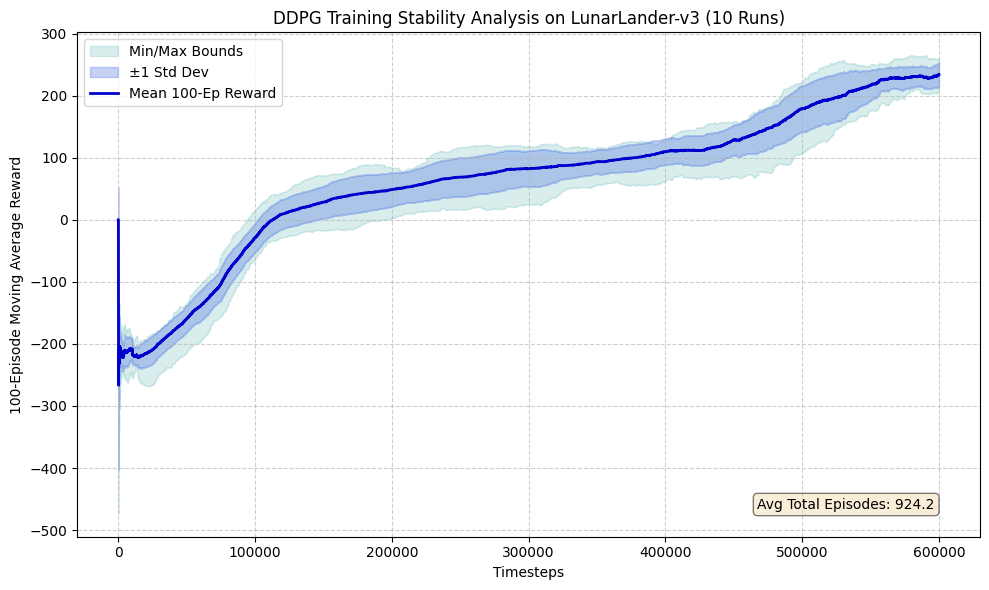

In [ ]:
# Configuration
N_RUNS = 10
SAVE_DIR = "./DDPG_stability_analysis"

all_runs_logs = []
all_runs_lengths_logs = []

print(f"Loading Stability Analysis data for {N_RUNS} runs from '{SAVE_DIR}'...")

# --- LOAD DATA FROM SAVED ARRAYS ---
for run in range(N_RUNS):
    reward_file = os.path.join(SAVE_DIR, f"run_{run+1}_rewards.npy")
    length_file = os.path.join(SAVE_DIR, f"run_{run+1}_episodes_count.npy")
    
    if os.path.exists(reward_file) and os.path.exists(length_file):
        # Load the step-by-step reward history
        run_history = np.load(reward_file).tolist()
        # Load the scalar episode count (.item() extracts the scalar from the 0D array)
        run_lengths_history = np.load(length_file).item()
        
        all_runs_logs.append(run_history)
        all_runs_lengths_logs.append(run_lengths_history)
        print(f"-> Successfully loaded Run {run + 1} (Total Episodes: {run_lengths_history})")
    else:
        raise FileNotFoundError(f"Missing data files for Run {run + 1}. Please ensure both {reward_file} and {length_file} exist.")

print("\nAll data loaded successfully! Processing metrics and generating stability plot...")

# --- PROCESS METRICS ---
# Convert to a 2D numpy array: shape (N_RUNS, timesteps_logged)
data_matrix = np.array(all_runs_logs)

# Calculate stats across the runs (axis=0)
mean_trend = np.mean(data_matrix, axis=0)
std_trend = np.std(data_matrix, axis=0)
min_trend = np.min(data_matrix, axis=0)
max_trend = np.max(data_matrix, axis=0)

# Since your training loop saved data at EVERY timestep, your effective LOG_FREQ is 1
effective_log_freq = 1
x_axis = np.arange(len(mean_trend)) * effective_log_freq

# --- PLOTTING ---
plt.figure(figsize=(10, 6))

# 1. Fill the Min/Max total range (Light Cyan shadow)
plt.fill_between(
    x_axis, 
    min_trend, 
    max_trend, 
    color="darkcyan", 
    alpha=0.15, 
    label="Min/Max Bounds"
)

# 2. Fill the Standard Deviation shadow (Royal Blue shadow)
plt.fill_between(
    x_axis, 
    mean_trend - std_trend, 
    mean_trend + std_trend, 
    color="royalblue", 
    alpha=0.3, 
    label="±1 Std Dev"
)

# 3. Plot the mean line (Deep Blue line)
plt.plot(x_axis, mean_trend, label="Mean 100-Ep Reward", color="mediumblue", lw=2)

# Graph embellishments
plt.title(f"DDPG Training Stability Analysis on LunarLander-v3 ({N_RUNS} Runs)")
plt.xlabel("Timesteps")
plt.ylabel("100-Episode Moving Average Reward")
plt.legend(loc="upper left")
plt.grid(True, linestyle="--", alpha=0.6)

# Display total average episodes completed across all runs as text on the plot
avg_final_episodes = np.mean(all_runs_lengths_logs)
plt.text(0.95, 0.05, f"Avg Total Episodes: {avg_final_episodes:.1f}", 
         transform=plt.gca().transAxes, ha="right", va="bottom",
         bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.show()